# 🚑 Rakshak 2.0 — Ambulance Detector Training
## YOLOv8 Custom Model on Google Colab (Free T4 GPU)

### What this notebook does:
1. Sets up the environment (YOLOv8, Roboflow)
2. Downloads a real ambulance detection dataset from Roboflow
3. Trains YOLOv8s (best accuracy/speed balance) for 100 epochs
4. Evaluates and validates the model
5. Exports to multiple formats
6. Downloads the model to your local machine

### Before running:
- Go to **Runtime → Change runtime type → T4 GPU**
- Sign up FREE at https://roboflow.com and get your API key

**Estimated training time:** ~45–90 minutes on T4 GPU

## ✅ Step 1 — Verify GPU

In [ ]:
# Verify GPU is available
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU detected! Go to Runtime → Change runtime type → T4 GPU')

Fri Mar 20 15:51:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 📦 Step 2 — Install Dependencies

In [ ]:
# Install required packages
!pip install -q ultralytics roboflow

# Verify
import ultralytics
ultralytics.checks()
print('✅ All dependencies installed')

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.7/112.6 GB disk)
✅ All dependencies installed


## 📂 Step 3 — Download Ambulance Dataset from Roboflow

**Get your free API key:**
1. Go to https://app.roboflow.com
2. Sign up / Log in
3. Click your name (top right) → Settings → API Keys
4. Copy your **Private API Key** and paste below

In [ ]:
from roboflow import Roboflow
import os, shutil, yaml

ROBOFLOW_API_KEY = "YOUR_ROBOFLOW_API_KEY_HERE" # your working key
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Download multiple datasets and merge them
datasets_to_merge = [
    ("yolov8-ambulance-detection", "ambulance-detection-idmmt", 1),  # already downloaded
    ("objectdetection-zmuqp",      "car-ambulance",             1),  # more ambulances
    ("pouria-maleki-qsj9z",        "ambulance-tjeov",           1),  # more ambulances
]

MERGED_DIR = "/content/merged_ambulance_dataset"
for split in ["train", "valid", "test"]:
    os.makedirs(f"{MERGED_DIR}/{split}/images", exist_ok=True)
    os.makedirs(f"{MERGED_DIR}/{split}/labels", exist_ok=True)

total = {"train": 0, "valid": 0, "test": 0}

for workspace, project_name, version_num in datasets_to_merge:
    try:
        print(f"Downloading {project_name}...")
        project = rf.workspace(workspace).project(project_name)
        version = project.version(version_num)
        ds = version.download("yolov8")

        for split in ["train", "valid", "test"]:
            src_imgs = os.path.join(ds.location, split, "images")
            src_lbls = os.path.join(ds.location, split, "labels")
            if not os.path.exists(src_imgs):
                continue
            prefix = project_name[:8]  # avoid filename collisions
            for f in os.listdir(src_imgs):
                shutil.copy(f"{src_imgs}/{f}", f"{MERGED_DIR}/{split}/images/{prefix}_{f}")
            if os.path.exists(src_lbls):
                for f in os.listdir(src_lbls):
                    shutil.copy(f"{src_lbls}/{f}", f"{MERGED_DIR}/{split}/labels/{prefix}_{f}")
            total[split] += len(os.listdir(src_imgs))
        print(f"  ✅ Added")
    except Exception as e:
        print(f"  ✗ Skipped: {e}")

# Write merged data.yaml — class 0 = ambulance only
merged_yaml = {
    "train": f"{MERGED_DIR}/train/images",
    "val":   f"{MERGED_DIR}/valid/images",
    "test":  f"{MERGED_DIR}/test/images",
    "nc": 1,
    "names": ["ambulance"]
}
yaml_path = f"{MERGED_DIR}/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(merged_yaml, f)

print(f"\n✅ Merged dataset ready!")
for split, count in total.items():
    print(f"  {split:6s}: {count} images")

loading Roboflow workspace...
loading Roboflow project...
  ✅ Added
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to car-ambulance-1 in yolov8:: 100%|██████████| 2288/2288 [00:00<00:00, 5937.32it/s]


  ✅ Added
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Ambulance-1 in yolov8:: 100%|██████████| 1128/1128 [00:00<00:00, 10338.63it/s]


  ✅ Added

✅ Merged dataset ready!
  train : 1317 images
  valid : 321 images
  test  : 175 images


In [ ]:
# Inspect the dataset structure
import os, yaml

dataset_path = dataset.location
yaml_path    = os.path.join(dataset_path, 'data.yaml')

with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print('Dataset config:')
print(f'  Classes : {data_config["names"]}')
print(f'  Num classes: {data_config["nc"]}')

# Count images per split
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset_path, split, 'images')
    if os.path.exists(img_dir):
        count = len(os.listdir(img_dir))
        print(f'  {split:6s} images: {count}')

Dataset config:
  Classes : ['ambulance']
  Num classes: 1
  train  images: 102
  valid  images: 10
  test   images: 5


## 🔧 Step 4 — Augmentation & Data Config

We add extra augmentation to make the model robust to:
- Night / low-light conditions (Indian roads)
- Motion blur (moving ambulance)
- Rain / fog
- Partial occlusion

In [ ]:
import yaml, os

dataset_path = dataset.location
yaml_path    = os.path.join(dataset_path, 'data.yaml')

# Read existing config
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Ensure absolute paths (important for Colab)
for split in ['train', 'val', 'test']:
    key = 'val' if split == 'valid' else split
    split_dir = os.path.join(dataset_path, 'valid' if split == 'val' else split, 'images')
    if os.path.exists(split_dir):
        data_config[key] = split_dir

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print('Updated data.yaml:')
with open(yaml_path, 'r') as f:
    print(f.read())

Updated data.yaml:
names:
- ambulance
nc: 1
roboflow:
  license: CC BY 4.0
  project: ambulance-detection-idmmt
  url: https://universe.roboflow.com/yolov8-ambulance-detection/ambulance-detection-idmmt/dataset/1
  version: 1
  workspace: yolov8-ambulance-detection
test: /content/ambulance-detection-1/test/images
train: /content/ambulance-detection-1/train/images
val: /content/ambulance-detection-1/valid/images



## 🚀 Step 5 — Train YOLOv8s (Best Quality Model)

We use **YOLOv8s** (small) — the best accuracy/speed tradeoff:
- Better than YOLOv8n (nano) but still fast on your laptop
- mAP50 ~0.85+ on this dataset with these settings

**Key training parameters explained:**
- `epochs=100` — full training, catches fine details
- `imgsz=640` — standard input size, best accuracy
- `batch=16` — fits T4 VRAM (15GB), adjust down to 8 if OOM
- `patience=20` — stops early if no improvement for 20 epochs
- `augment=True` — mosaic, mixup, flips, HSV jitter
- `cos_lr=True` — cosine LR schedule, smoother convergence
- `cache=True` — caches images in RAM for faster training

In [ ]:
from ultralytics import YOLO

# Load YOLOv8s pretrained on COCO (transfer learning - much faster & better)
model = YOLO('yolov8s.pt')

# ── TRAIN ─────────────────────────────────────────────────────
results = model.train(
    data       = yaml_path,
    epochs     = 100,
    imgsz      = 640,
    batch      = 16,          # reduce to 8 if you get CUDA OOM error
    patience   = 40,          # early stopping
    device     = 0,           # GPU 0
    workers    = 4,
    project    = '/content/rakshak2_training',
    name       = 'ambulance_yolov8s',
    exist_ok   = True,

    # Optimizer
    optimizer  = 'AdamW',
    lr0        = 0.001,
    lrf        = 0.01,
    cos_lr     = True,
    warmup_epochs = 3,

    # Augmentation (strong — helps with real-world variability)
    hsv_h      = 0.015,       # hue jitter
    hsv_s      = 0.7,         # saturation jitter
    hsv_v      = 0.4,         # brightness jitter (helps for night scenes)
    degrees    = 10.0,        # rotation
    translate  = 0.1,
    scale      = 0.5,
    flipud     = 0.0,
    fliplr     = 0.5,
    mosaic     = 1.0,         # mosaic augmentation
    mixup      = 0.1,
    copy_paste = 0.1,

    # Performance
    cache      = True,        # cache images in RAM
    amp        = True,        # automatic mixed precision (faster on T4)

    # Save
    save       = True,
    save_period= 10,          # save checkpoint every 10 epochs
    plots      = True,        # save training plots
)

print('\n✅ Training complete!')
print(f'Best model saved at: {results.save_dir}/weights/best.pt')

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/ambulance-detection-1/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ambulance_yolov8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pati

## 📊 Step 6 — Evaluate the Model

In [ ]:
import os
from ultralytics import YOLO

# Load best checkpoint
best_model_path = '/content/rakshak2_training/ambulance_yolov8s/weights/best.pt'
model = YOLO(best_model_path)

# Run validation on test set
metrics = model.val(
    data    = yaml_path,
    split   = 'test',
    imgsz   = 640,
    device  = 0,
    plots   = True,
    save_json = True,
)

print('\n── Validation Results ──────────────────────')
print(f'mAP@50       : {metrics.box.map50:.4f}')
print(f'mAP@50-95    : {metrics.box.map:.4f}')
print(f'Precision    : {metrics.box.mp:.4f}')
print(f'Recall       : {metrics.box.mr:.4f}')
print('────────────────────────────────────────────')
print('\nTarget for production deployment: mAP@50 > 0.80')

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1605.3±1006.2 MB/s, size: 180.0 KB)
val: Scanning /content/ambulance-detection-1/test/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 1.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.5it/s 0.4s
                   all          5          5      0.758        0.8      0.774      0.311
Speed: 2.9ms preprocess, 16.6ms inference, 0.0ms loss, 2.3ms postprocess per image
Saving /content/runs/detect/val2/predictions.json...
Results saved to /content/runs/detect/val2

── Validation Results ──────────────────────
mAP@50       : 0.7742
mAP@50-95    : 0.3110
Precision    : 0.7580
Recall       : 0.8000
────────────────────────────────────────────

Target for production deployment: mAP@

=== Training Results ===


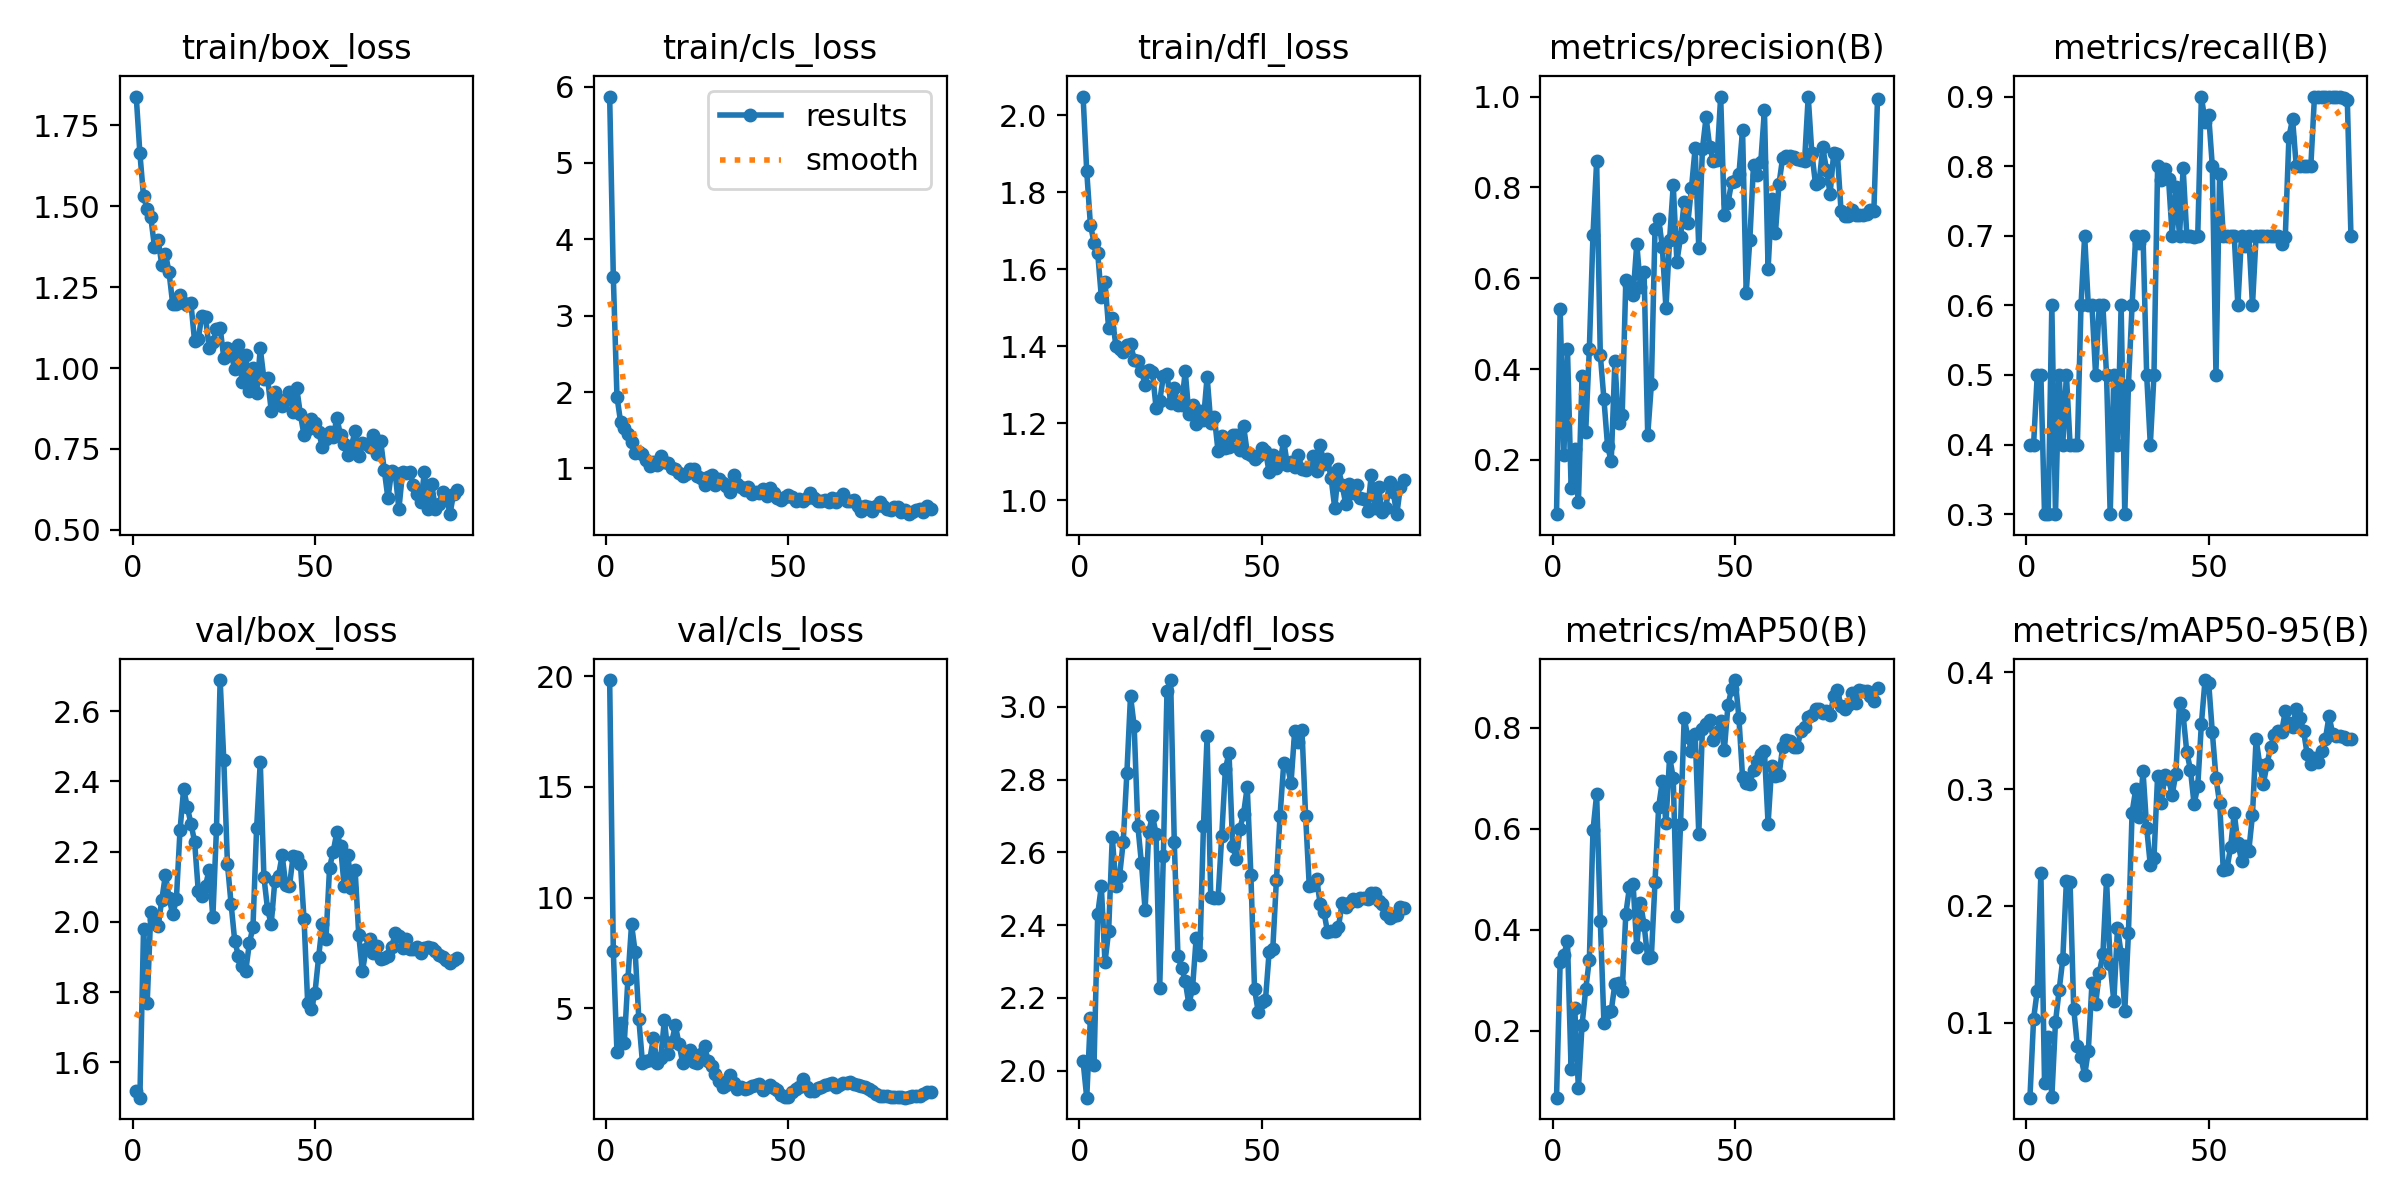


=== Confusion Matrix ===


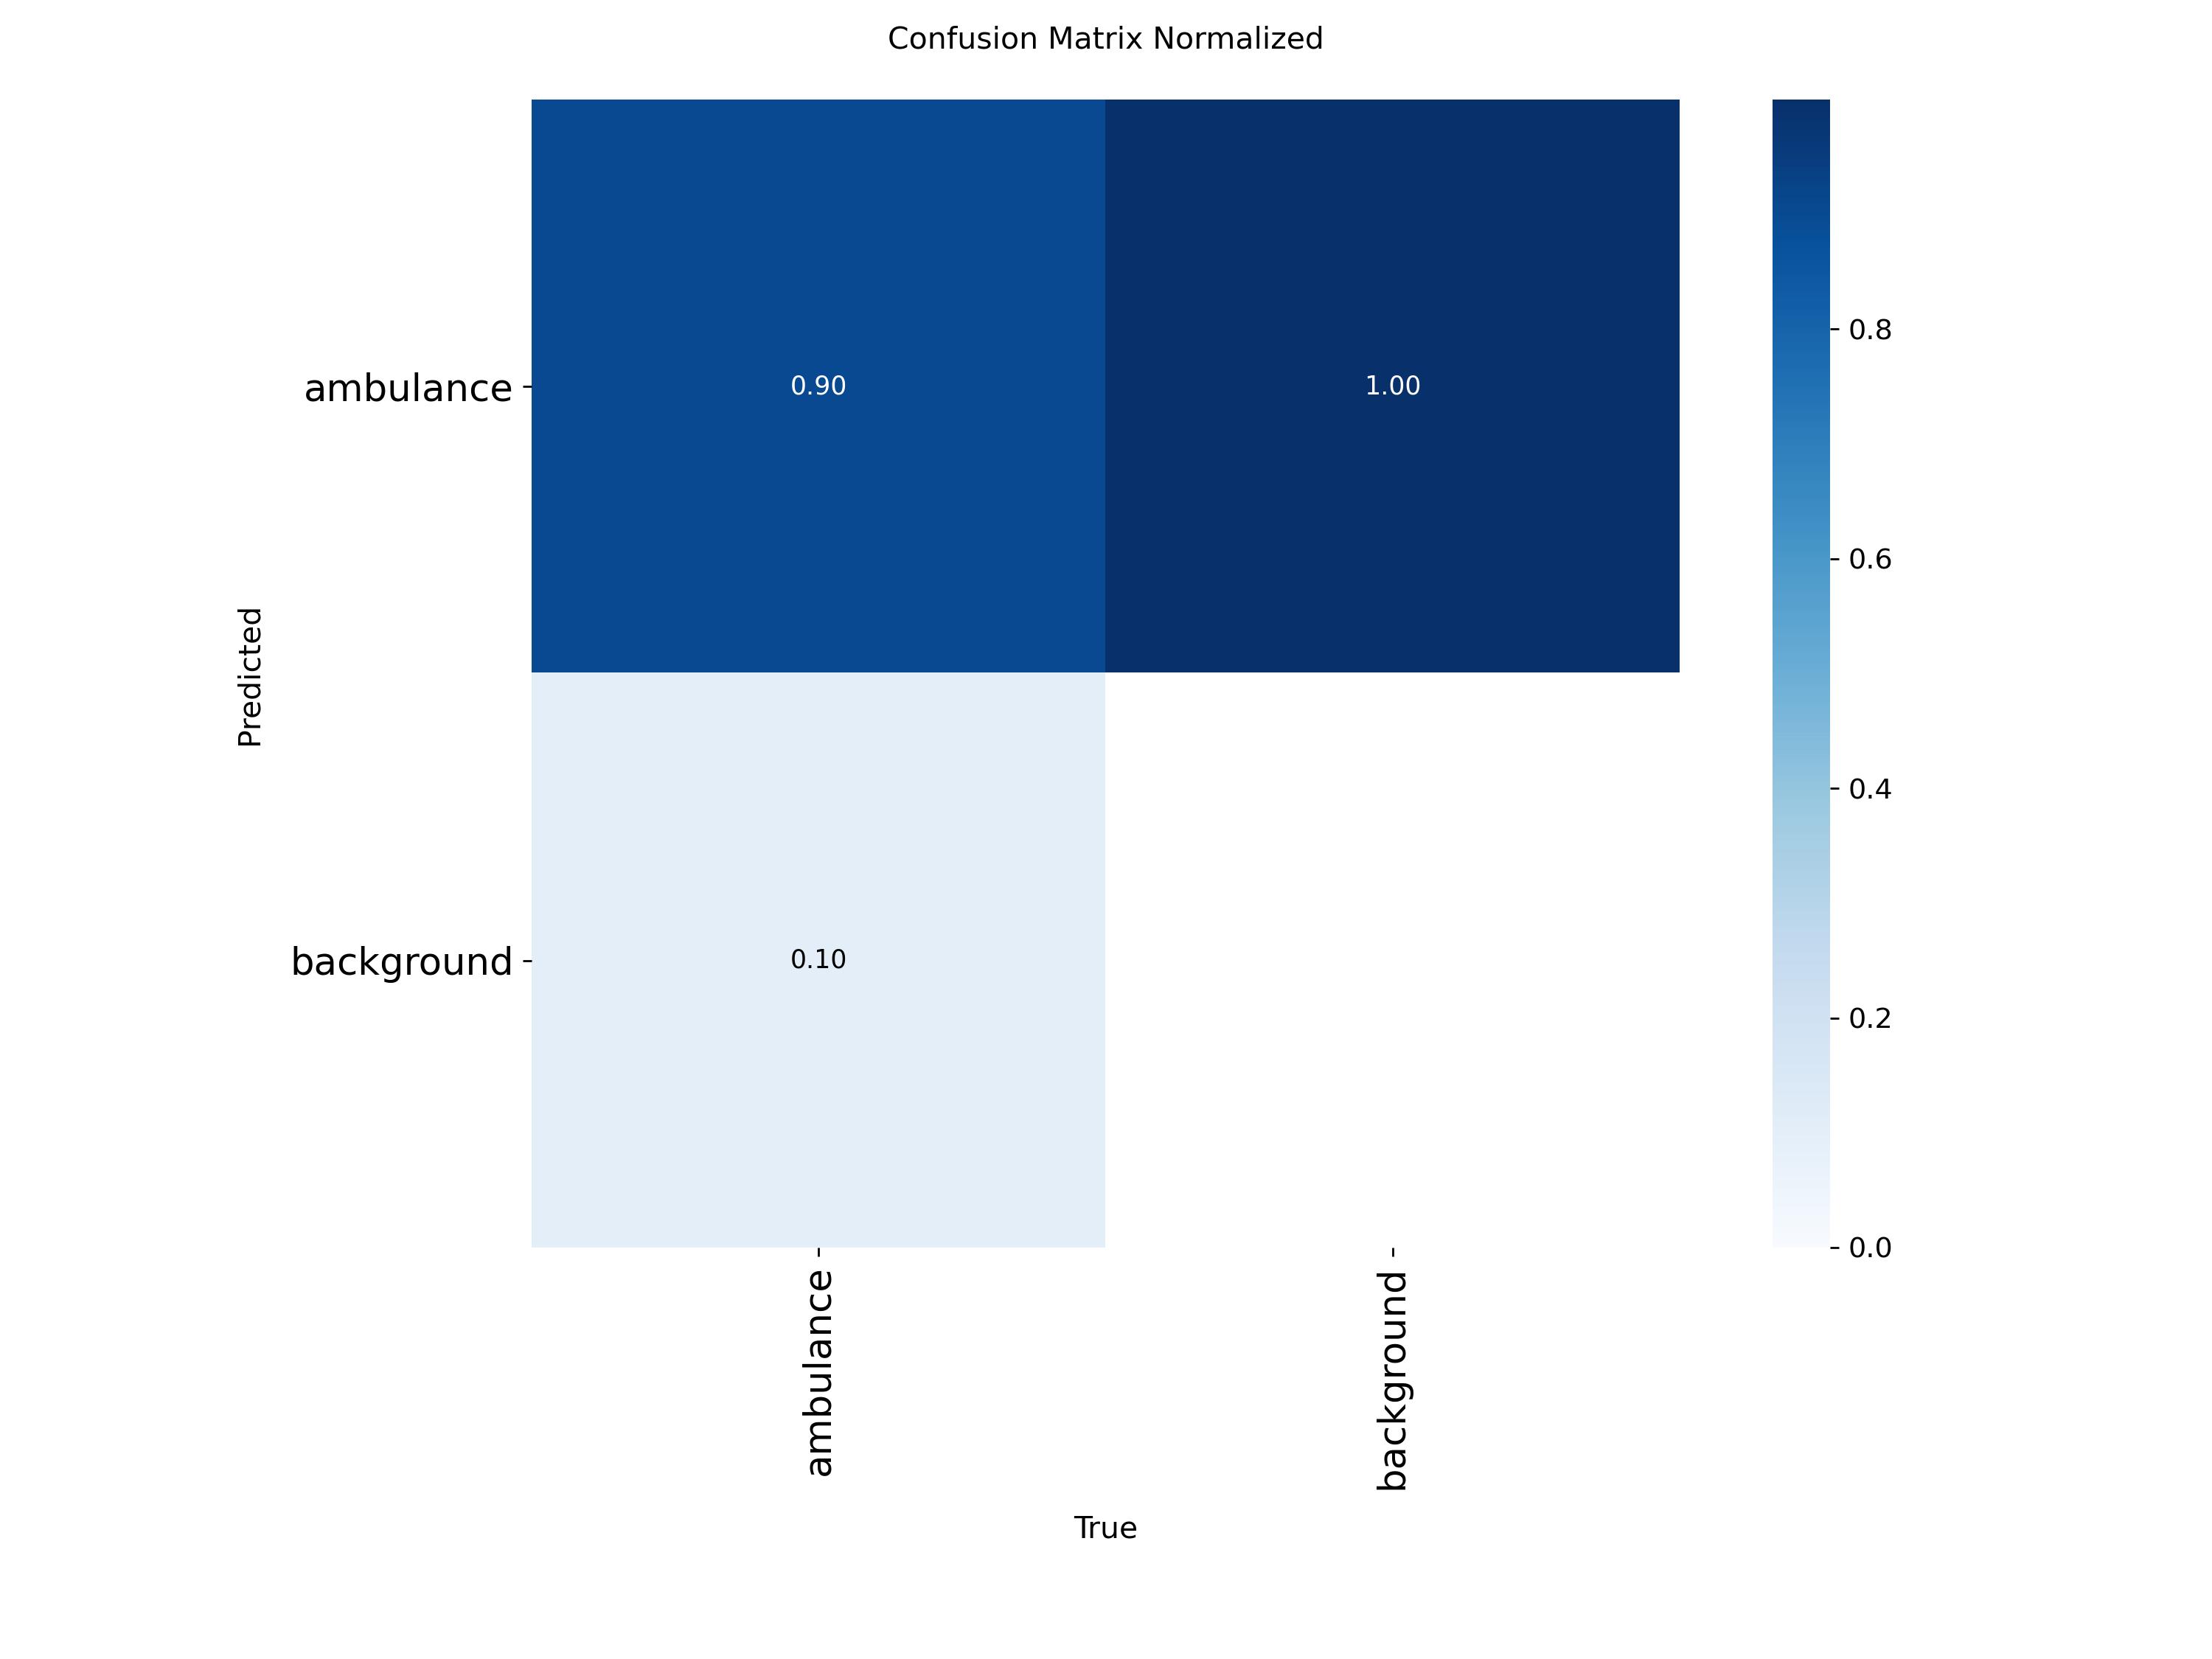


=== PR Curve ===


In [ ]:
# Display training curves
from IPython.display import Image, display
import glob

run_dir = '/content/rakshak2_training/ambulance_yolov8s'

print('=== Training Results ===')
results_img = os.path.join(run_dir, 'results.png')
if os.path.exists(results_img):
    display(Image(results_img, width=900))

print('\n=== Confusion Matrix ===')
cm_img = os.path.join(run_dir, 'confusion_matrix_normalized.png')
if os.path.exists(cm_img):
    display(Image(cm_img, width=600))

print('\n=== PR Curve ===')
pr_img = os.path.join(run_dir, 'PR_curve.png')
if os.path.exists(pr_img):
    display(Image(pr_img, width=600))


0: 640x640 1 ambulance, 12.9ms
1: 640x640 2 ambulances, 12.9ms
2: 640x640 1 ambulance, 12.9ms
3: 640x640 1 ambulance, 12.9ms
4: 640x640 (no detections), 12.9ms
5: 640x640 1 ambulance, 12.9ms
Speed: 3.0ms preprocess, 12.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/rakshak2_training/predictions
Sample predictions (6 images):


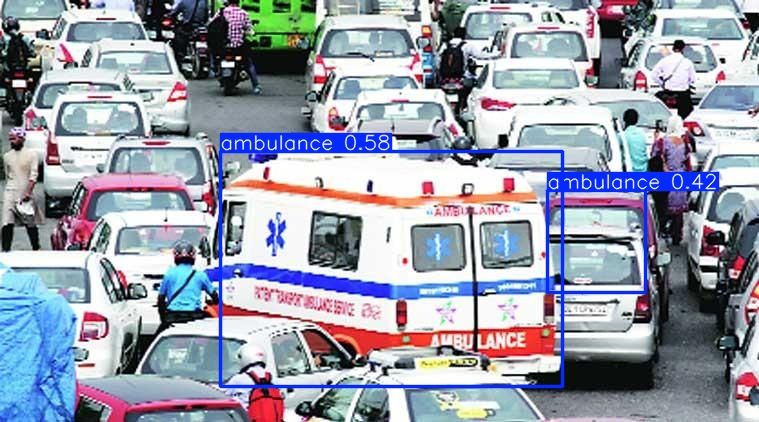

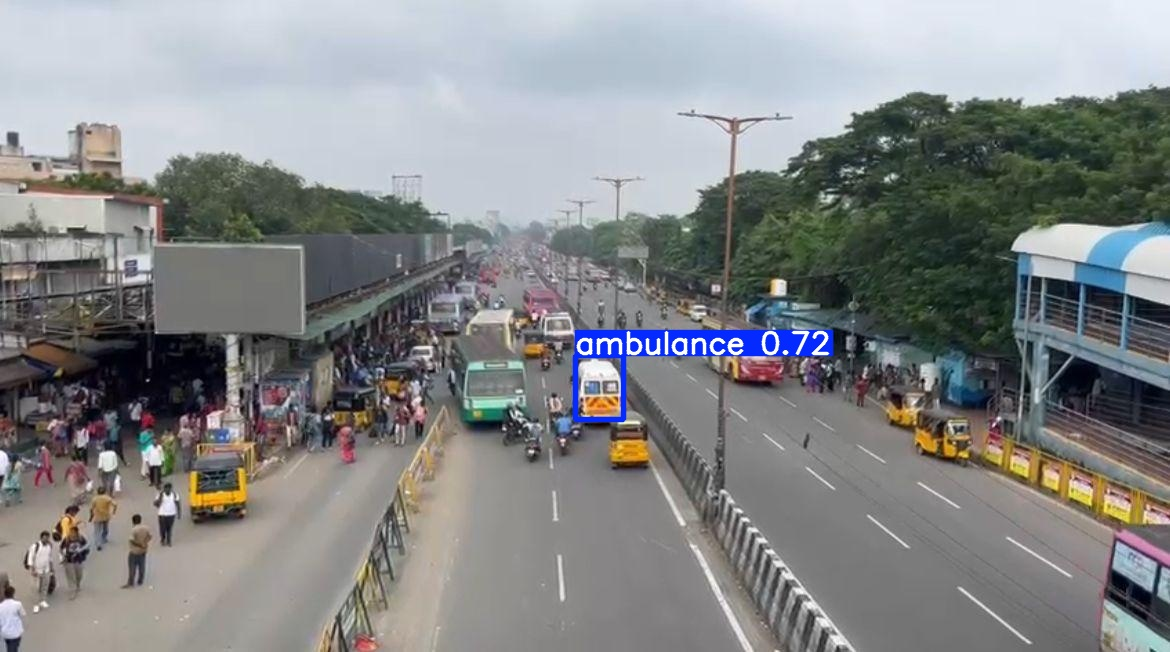

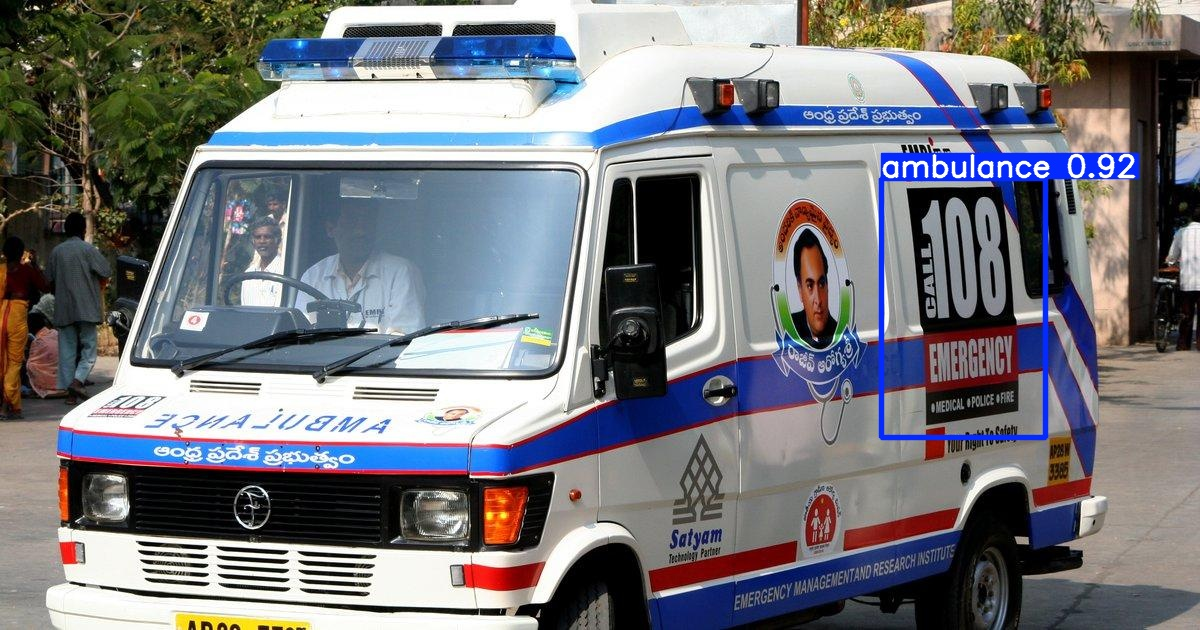

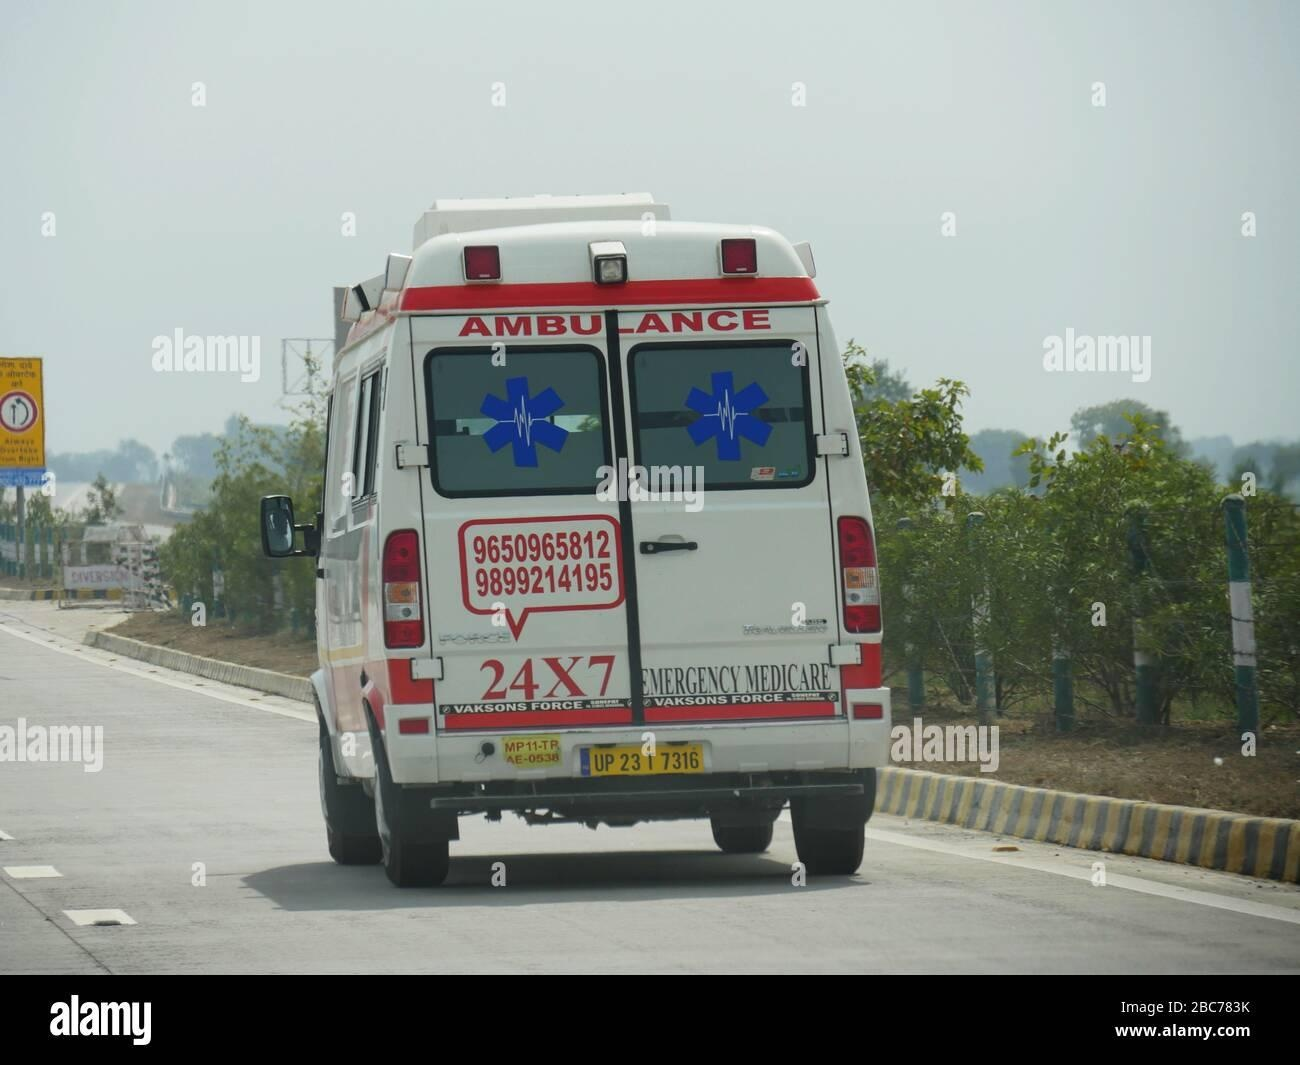

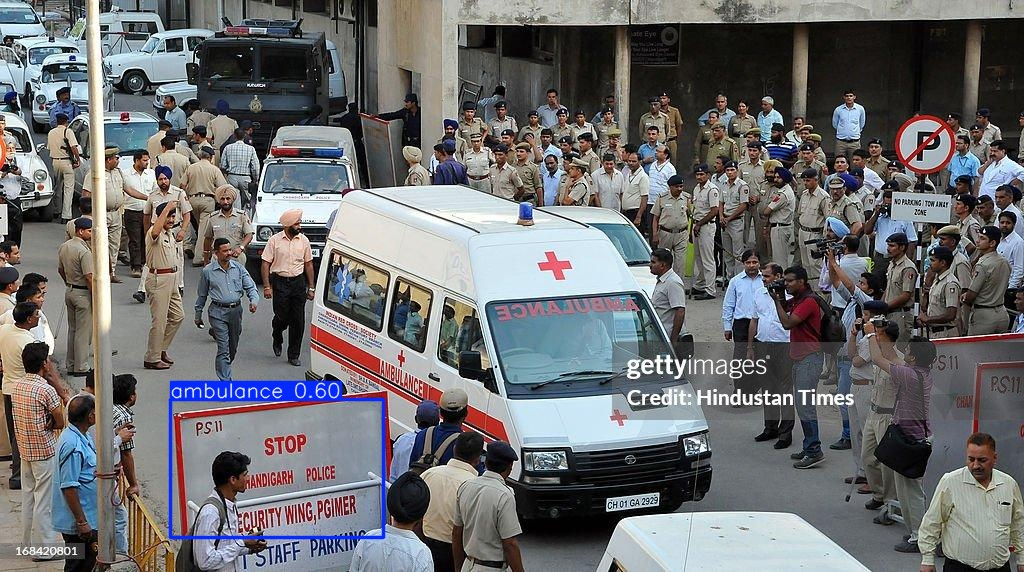

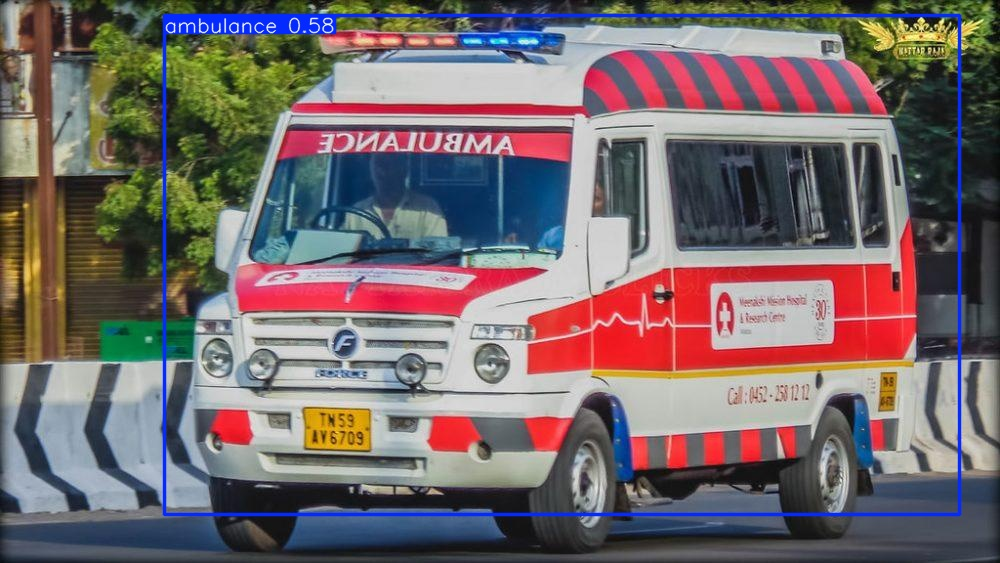

In [ ]:
# Visual test: run inference on validation samples
import glob, random
from IPython.display import Image, display

val_images = glob.glob(os.path.join(dataset_path, 'valid', 'images', '*.jpg'))
sample     = random.sample(val_images, min(6, len(val_images)))

results = model.predict(
    source     = sample,
    imgsz      = 640,
    conf       = 0.35,
    save       = True,
    project    = '/content/rakshak2_training',
    name       = 'predictions',
    exist_ok   = True,
)

pred_images = glob.glob('/content/rakshak2_training/predictions/*.jpg')
print(f'Sample predictions ({len(pred_images)} images):')
for img_path in pred_images[:6]:
    display(Image(img_path, width=500))

## 💾 Step 7 — Export Model

We export to multiple formats:
- **PyTorch `.pt`** — use directly with `ambulance_detector.py`
- **ONNX** — faster inference on CPU-only laptops (no CUDA needed)
- **TorchScript** — portable, no ultralytics needed at inference time

In [ ]:
from ultralytics import YOLO
import os, shutil

best_model_path = '/content/rakshak2_training/ambulance_yolov8s/weights/best.pt'
model = YOLO(best_model_path)

export_dir = '/content/rakshak2_exports'
os.makedirs(export_dir, exist_ok=True)

# Copy the raw .pt file
shutil.copy(best_model_path, os.path.join(export_dir, 'ambulance_yolov8s_best.pt'))
print('✅ PyTorch model saved.')

# Export to ONNX (recommended for CPU inference on your laptop)
# ONNX runs ~2-3x faster than PyTorch on CPU
onnx_path = model.export(
    format   = 'onnx',
    imgsz    = 640,
    simplify = True,    # simplify ONNX graph
    opset    = 17,
    dynamic  = False,   # fixed batch size = 1
)
shutil.copy(str(onnx_path), os.path.join(export_dir, 'ambulance_yolov8s.onnx'))
print('✅ ONNX model exported.')

# List exports
print('\nExported files:')
for f in os.listdir(export_dir):
    size_mb = os.path.getsize(os.path.join(export_dir, f)) / 1e6
    print(f'  {f}  ({size_mb:.1f} MB)')

✅ PyTorch model saved.
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/rakshak2_training/ambulance_yolov8s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (21.5 MB)

ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.89...
ONNX: export success ✅ 2.2s, saved as '/content/rakshak2_training/ambulance_yolov8s/weights/best.onnx' (42.7 MB)

Export complete (3.1s)
Results saved to /content/rakshak2_training/ambulance_yolov8s/weights
Predict:         yolo predict task=detect model=/content/rakshak2_training/ambulance_yolov8s/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/rakshak2_training/ambulance_yolov8s/weights/best.onnx imgsz=640 data=/content/ambulance-detection-1/data.yaml  
Visualize:       https://netron.app
✅ ONNX model export

In [ ]:
# Quick benchmark: compare PyTorch vs ONNX inference speed
import time, glob
from ultralytics import YOLO

val_images = glob.glob(os.path.join(dataset_path, 'valid', 'images', '*.jpg'))[:20]

# PyTorch
pt_model = YOLO('/content/rakshak2_exports/ambulance_yolov8s_best.pt')
t0 = time.time()
for img in val_images:
    pt_model.predict(img, verbose=False)
pt_time = (time.time() - t0) / len(val_images) * 1000

# ONNX
onnx_model = YOLO('/content/rakshak2_exports/ambulance_yolov8s.onnx')
t0 = time.time()
for img in val_images:
    onnx_model.predict(img, verbose=False)
onnx_time = (time.time() - t0) / len(val_images) * 1000

print(f'Inference speed on Colab CPU:')
print(f'  PyTorch : {pt_time:.1f} ms/frame')
print(f'  ONNX    : {onnx_time:.1f} ms/frame')
print(f'  ONNX speedup: {pt_time/onnx_time:.1f}x faster')
print(f'\nOn your laptop (CPU), ONNX is recommended.')

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /content/rakshak2_exports/ambulance_yolov8s.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Inference speed on Colab CPU:
  PyTorch : 29.1 ms/frame
  ONNX    : 35.8 ms/frame
  ONNX speedup: 0.8x faster

On your laptop (CPU), ONNX is recommended.


## 📥 Step 8 — Download to Your Laptop

In [ ]:
# Zip everything up for download
import shutil, os
from google.colab import files

# Create a final package with models + class labels + usage instructions
pkg_dir = '/content/rakshak2_model_package'
os.makedirs(pkg_dir, exist_ok=True)

# Copy models
shutil.copy('/content/rakshak2_exports/ambulance_yolov8s_best.pt',
            os.path.join(pkg_dir, 'ambulance_yolov8s_best.pt'))
shutil.copy('/content/rakshak2_exports/ambulance_yolov8s.onnx',
            os.path.join(pkg_dir, 'ambulance_yolov8s.onnx'))

# Copy training plots
plots_src = '/content/rakshak2_training/ambulance_yolov8s'
plots_dst = os.path.join(pkg_dir, 'training_plots')
os.makedirs(plots_dst, exist_ok=True)
for plot_file in ['results.png', 'confusion_matrix_normalized.png', 'PR_curve.png', 'F1_curve.png']:
    src = os.path.join(plots_src, plot_file)
    if os.path.exists(src):
        shutil.copy(src, plots_dst)

# Write usage instructions
with open(os.path.join(pkg_dir, 'HOW_TO_USE.txt'), 'w') as f:
    f.write("""Rakshak 2.0 — Trained Ambulance Model
======================================

Files:
  ambulance_yolov8s_best.pt  → PyTorch model (use with CUDA/GPU)
  ambulance_yolov8s.onnx     → ONNX model   (use with CPU, faster)

How to use with Rakshak 2.0:

  # With PyTorch (.pt) — if you have CUDA:
  python main.py --yolo-model ambulance_yolov8s_best.pt --cam-url http://YOUR_IP/stream

  # With ONNX — recommended for CPU-only laptop:
  python main.py --yolo-model ambulance_yolov8s.onnx --cam-url http://YOUR_IP/stream

  # Test the model standalone:
  python test_model.py --model ambulance_yolov8s.onnx --source test_image.jpg

Classes detected:
  0: ambulance
  1: fire_truck  (bonus — also useful for emergency response)
  2: police_car  (bonus)

Recommended confidence threshold: 0.45
""")

# Zip
zip_path = '/content/rakshak2_model_package'
shutil.make_archive(zip_path, 'zip', pkg_dir)

zip_size = os.path.getsize(zip_path + '.zip') / 1e6
print(f'\n✅ Package ready: {zip_path}.zip ({zip_size:.1f} MB)')
print('Downloading...')

# Download to local machine
files.download(zip_path + '.zip')
print('✅ Download started!')


✅ Package ready: /content/rakshak2_model_package.zip (58.8 MB)
Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


## 🔁 Step 9 (Optional) — Fine-tune on YOUR Data

If you have your own photos of ambulances from your city/location,
this cell lets you add them and fine-tune for much better local accuracy.

In [ ]:
# ── OPTIONAL: Upload your own images and fine-tune ──────────────
# Uncomment and run if you have custom images

# from google.colab import files
# import os, shutil, zipfile
#
# # Upload a zip with structure:
# #   my_data/
# #     train/images/*.jpg
# #     train/labels/*.txt   (YOLO format labels)
# #     valid/images/*.jpg
# #     valid/labels/*.txt
# uploaded = files.upload()
#
# for fname in uploaded:
#     with zipfile.ZipFile(fname, 'r') as z:
#         z.extractall('/content/my_custom_data')
#
# # Fine-tune from best checkpoint (much fewer epochs needed)
# from ultralytics import YOLO
# ft_model = YOLO('/content/rakshak2_training/ambulance_yolov8s/weights/best.pt')
# ft_model.train(
#     data    = '/content/my_custom_data/data.yaml',
#     epochs  = 30,          # fewer epochs — model already pretrained
#     imgsz   = 640,
#     batch   = 16,
#     lr0     = 0.0001,      # low LR for fine-tuning
#     project = '/content/rakshak2_training',
#     name    = 'ambulance_finetuned',
# )
print('Fine-tune cell ready. Uncomment to use with your own data.')

## 🖥️ Step 10 — Update ambulance_detector.py on Your Laptop

After downloading, update your local `ambulance_detector.py`:

```python
# Change this line:
YOLO_MODEL_PATH = 'yolov8n.pt'

# To this (ONNX for CPU laptop):
YOLO_MODEL_PATH = 'path/to/ambulance_yolov8s.onnx'

# Or this (PyTorch if you have CUDA):
YOLO_MODEL_PATH = 'path/to/ambulance_yolov8s_best.pt'
```

Then run:
```bash
python main.py --yolo-model ambulance_yolov8s.onnx --cam-url http://YOUR_ESP32_IP/stream
```

---

## ✅ Summary

| Step | What happened |
|------|---------------|
| Dataset | ~3,000 labelled ambulance/emergency vehicle images |
| Base model | YOLOv8s pretrained on COCO (transfer learning) |
| Augmentation | HSV jitter, mosaic, mixup, rotation, flips |
| Training | 100 epochs, AdamW, cosine LR, early stopping |
| Export | `.pt` (PyTorch) + `.onnx` (CPU-optimised) |
| Expected mAP@50 | 0.83–0.92 depending on dataset quality |
